# Fake Review Detection: A Comparative Analysis

**Module:** MSIN0221 — Natural Language Processing (2025/26)
**Institution:** University College London

---

**Research Question:** How do error rates in fake review detection models vary across review length and star rating, and does a transformer-based model reduce these errors more consistently than a bag-of-words baseline?

## Technical Setup

The following cells load all required libraries, define global constants, and initialise shared preprocessing utilities. All output directories (`outputs/figures/`, `outputs/metrics/`, `outputs/models/`) are created automatically on first run. This section must be executed before any analytical code in the notebook.

In [1]:
import json
import re
import ssl

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from datetime import datetime
from pathlib import Path
from scipy.sparse import hstack
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score, recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# NLTK downloads — SSL workaround for macOS certificate errors
import nltk
_ssl_ctx = ssl._create_unverified_context
ssl._create_default_https_context = _ssl_ctx
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("stopwords", quiet=True)
ssl._create_default_https_context = ssl.create_default_context

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

### Configuration

All constants — dataset identifiers, column names, label mappings, model hyperparameters, and output paths — are defined in a single block. Centralising configuration in this way ensures consistency and reproducibility: changing a hyperparameter here propagates automatically to all downstream cells.

In [2]:
# -----------------------------------------------------------------------
# Dataset (Hugging Face identifier)
# -----------------------------------------------------------------------
DATASET_NAME = "theArijitDas/Fake-Reviews-Dataset"
SPLIT_NAME   = "train"  # HF split name — not our train/test split

# Column names in the raw dataset
TEXT_COL     = "text"
LABEL_COL    = "label"
RATING_COL   = "rating"
CATEGORY_COL = "category"

# Label mapping: 0 = human-written, 1 = computer-generated (as per dataset docs)
LABEL_MAP = {
    0: "genuine",
    1: "fake",
}

# -----------------------------------------------------------------------
# Phase 2 settings
# -----------------------------------------------------------------------
RANDOM_SEED = 42
TEST_SIZE   = 0.2

# Feature columns
WORD_COUNT_COL = "n_words"
RATING_BIN_COL = "rating_bin"
LENGTH_BIN_COL = "length_bin"

# TF-IDF parameters — unigrams (Baseline A)
TFIDF_PARAMS = {
    "ngram_range": (1, 1),
    "max_features": 5000,
    "min_df": 2,
    "stop_words": "english",
}

# TF-IDF parameters — unigrams + bigrams (Baseline A-bigram)
TFIDF_BIGRAM_PARAMS = {
    "ngram_range": (1, 2),
    "max_features": 10000,
    "min_df": 2,
    "stop_words": "english",
}

# Logistic Regression parameters
LOGREG_PARAMS = {
    "C": 1.0,
    "max_iter": 2000,
    "class_weight": None,
}

# -----------------------------------------------------------------------
# Output paths
# -----------------------------------------------------------------------
OUT_DIR     = Path("outputs")
FIG_DIR     = OUT_DIR / "figures"
TAB_DIR     = OUT_DIR / "tables"
MODEL_DIR   = OUT_DIR / "models"
METRICS_DIR = OUT_DIR / "metrics"   # EDA and evaluation statistics

CLEAN_DATA_PATH = TAB_DIR / "train_clean.csv"

for d in [OUT_DIR, FIG_DIR, TAB_DIR, MODEL_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

### Shared Utilities

Feature engineering functions (word and character count, rating bin assignment) and the five-stage text preprocessing pipeline (lowercasing → punctuation removal → tokenisation → stopword removal → lemmatisation) are defined here. These utilities are shared across data exploration, baseline modelling, and transformer preparation to guarantee consistent text representations throughout the analysis.

In [3]:
def add_length_features(df):
    """
    Add n_chars and n_words columns.
    Uses a simple whitespace split for n_words — retained as a lightweight
    metadata feature for baseline models. review_length (proper token count)
    is computed separately from clean_text after preprocessing.
    """
    df = df.copy()
    df["n_chars"] = df[TEXT_COL].astype(str).str.len()
    df["n_words"] = df[TEXT_COL].astype(str).str.split().str.len()
    return df


def validate_rating_scale(df):
    """Check for missing ratings and confirm the min/max are within expected 1–5 range."""
    return {
        "missing_ratings": int(df[RATING_COL].isna().sum()),
        "rating_min":      float(df[RATING_COL].dropna().min()),
        "rating_max":      float(df[RATING_COL].dropna().max()),
    }


def bin_rating(r):
    """
    Map a numeric star rating to a category: low (1–2), medium (3), high (4–5).
    Returns 'missing' for NaN — we keep these visible rather than dropping them.
    Used in Phase 2 metadata features and Phase 4 error analysis.
    """
    if r != r:  # NaN != NaN
        return "missing"
    if r <= 2:
        return "low"
    elif r == 3:
        return "medium"
    else:
        return "high"


def add_rating_bins(df):
    """Add a rating_bin column using bin_rating()."""
    df = df.copy()
    df["rating_bin"] = df[RATING_COL].apply(bin_rating)
    return df


def _save_text(lines, filename):
    path = TAB_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")
    return path

In [4]:
# -----------------------------------------------------------------------
# Text preprocessing — shared across Phase 1 (clean_text) and Phase 2 (TF-IDF)
# -----------------------------------------------------------------------
_lemmatizer = WordNetLemmatizer()
_PUNCT_RE   = re.compile(r"[^\w\s]")
_STOP_WORDS = set(stopwords.words("english"))


def preprocess_text(text):
    """
    Full text preprocessing pipeline (single implementation used by all phases):
      1. Lowercase
      2. Punctuation removal
      3. Tokenisation     (NLTK word_tokenize)
      4. Stopword removal (NLTK English stopword list)
      5. Lemmatisation    (WordNet lemmatizer)

    Used in Phase 1 to build clean_text / review_length, and in Phase 2
    as input to TF-IDF vectorisation.
    """
    text   = str(text).lower()
    text   = _PUNCT_RE.sub("", text)
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(t) for t in tokens if t not in _STOP_WORDS]
    return " ".join(tokens)

---

# 1. Introduction

## 1.1 Background and Motivation

The proliferation of online consumer reviews has made review platforms a primary information source for purchasing decisions. Concurrent advances in large language models have, however, made it substantially easier to generate plausible-sounding but deceptive reviews at scale. Fake reviews — whether written by humans for payment or generated automatically by machine — distort consumer choice, undermine platform credibility, and impose regulatory compliance risk on businesses (Luca & Zervas, 2016; Mukherjee et al., 2013).

Automated fake review detection is therefore a problem of both practical and scientific importance. The task sits at the intersection of text classification, authorship analysis, and the broader challenge of machine-generated text detection — a rapidly moving frontier as generative model capability continues to improve.

## 1.2 Research Gap

Prior work has established that supervised classifiers can distinguish human-written from machine-generated text with moderate accuracy (Ott et al., 2011; Perez-Rosas et al., 2015). However, relatively little attention has been paid to *where* these models fail: specifically, whether error rates are systematically elevated for certain review characteristics — such as length or expressed sentiment — that may make classification inherently harder. Understanding failure modes is critical for deploying such classifiers reliably in practice.

## 1.3 Research Question

> **How do error rates in fake review detection models vary across review length and star rating, and does a transformer-based model (BERT) reduce these errors more consistently than a bag-of-words baseline (TF-IDF + Logistic Regression)?**

## 1.4 Contributions

This study makes three contributions:

1. A systematic, subgroup-level error analysis of two representative model classes — bag-of-words (TF-IDF + Logistic Regression) and contextual transformer (BERT) — on a publicly available fake review benchmark.
2. An interaction analysis that identifies the (review length, star rating) subgroups that constitute structurally hard classification cases for both models.
3. An empirical comparison of where BERT provides consistent improvement over the baseline and where it does not, informing future model selection for this task.

## 1.5 Report Roadmap

Section 2 describes the dataset, preprocessing pipeline, model architectures, and evaluation framework. Section 3 presents the quantitative results. Section 4 interprets the findings in relation to the research question and situates them within the broader NLP literature. Sections 5 and 6 address limitations and conclusions respectively.

---

# 2. Data and Methodology

## 2.1 Dataset and Task Definition

The dataset is sourced from the Hugging Face Hub (`theArijitDas/Fake-Reviews-Dataset`) and comprises consumer product reviews labelled as either genuine (label = 0, human-written) or fake (label = 1, computer-generated). The task is formulated as binary text classification: given a review text and its associated star rating, predict whether the review was produced by a human or a language model.

Each record contains a free-text review body (`text`), a star rating (1–5), a product category, and a binary label following the original dataset documentation. After loading, label integrity is validated against the expected encoding. The review text is subsequently processed through the pipeline described in §2.2 to produce the `clean_text` feature used by both models.

The cells below load the dataset from Hugging Face, convert it to a Pandas DataFrame, and validate the label encoding.

In [5]:
print(f"Loading dataset: {DATASET_NAME} (split: {SPLIT_NAME})")
dataset = load_dataset(DATASET_NAME)
df = dataset[SPLIT_NAME].to_pandas()
print(f"Raw rows: {len(df)}")

Loading dataset: theArijitDas/Fake-Reviews-Dataset (split: train)


Raw rows: 40526


In [6]:
# Validate label values match our expected mapping {0: genuine, 1: fake}
unique_labels = sorted(df[LABEL_COL].dropna().unique())
if set(unique_labels) != set(LABEL_MAP.keys()):
    raise ValueError(
        f"Unexpected label values {unique_labels}. "
        f"Expected {list(LABEL_MAP.keys())}. Check LABEL_MAP in config."
    )
print(f"Label values confirmed: {unique_labels}")

Label values confirmed: [np.int64(0), np.int64(1)]


## 2.2 Data Preprocessing

The raw dataset undergoes three data quality steps: (1) rows with missing review text are dropped; (2) exact-duplicate texts are removed to prevent any form of data leakage; (3) a human-readable `label_name` field is derived for visualisation.

Text is subsequently processed through a five-stage pipeline: lowercasing, punctuation removal, NLTK word tokenisation, English stopword removal, and WordNet lemmatisation. For the Logistic Regression model, this preprocessed output is vectorised with TF-IDF. For BERT, the raw (unpipelined) text is used, as the HuggingFace tokeniser is optimised for natural language input and relies on subword structure that stopword removal and lemmatisation would damage. The `clean_text` column in all output files always refers to the preprocessed text.

In [7]:
n_missing = int(df[TEXT_COL].isna().sum())
df = df.dropna(subset=[TEXT_COL])

n_duplicates = int(df[TEXT_COL].duplicated().sum())
df = df.drop_duplicates(subset=[TEXT_COL])

df["label_name"] = df[LABEL_COL].map(LABEL_MAP)
df = df.reset_index(drop=True)
print(f"Removed {n_missing} missing and {n_duplicates} duplicate rows. Clean rows: {len(df)}")

Removed 0 missing and 33 duplicate rows. Clean rows: 40493


## 2.3 Feature Engineering and Grouping

**Numerical features.** Word count (`n_words`) and character count (`n_chars`) are derived from the preprocessed text. `n_words` is used as a lightweight numerical feature in the Logistic Regression metadata and combined models. Star rating is binned into a three-category `rating_bin` variable (low / medium / high) and one-hot encoded for metadata models.

**Review length grouping.** For error analysis, reviews are assigned to three equal-frequency length bins — *short*, *medium*, and *long* — using tertile quantile boundaries computed on the full dataset before any split. Tertile binning ensures balanced group sizes and avoids arbitrary threshold selection. The `length_bin` variable is intentionally excluded as a model feature; it serves exclusively as an analytical dimension in §3.2–3.4.

**Rating grouping.** Star ratings are grouped into three semantically coherent categories: *low* (1–2, negative sentiment), *medium* (3, neutral), and *high* (4–5, positive sentiment). This grouping reflects the tripartite sentiment structure common in consumer review research and ensures adequate subgroup sample sizes for the interaction analysis in §3.4.

In [8]:
df = add_length_features(df)
df = add_rating_bins(df)
rating_summary = validate_rating_scale(df)

# -----------------------------------------------------------------------
# Build clean_text and proposal-required feature columns
# -----------------------------------------------------------------------
print("Building clean_text (lowercase → punct removal → tokenise → stopwords → lemmatise)...")
print("This may take 1–2 minutes on ~40k reviews.")
df["clean_text"]    = df[TEXT_COL].apply(preprocess_text)
df["review_length"] = df["clean_text"].str.split().str.len()

# length_group: tertile-based bins from review_length (see grouping rationale above)
df["length_group"] = pd.qcut(
    df["review_length"],
    q=3,
    labels=["short", "medium", "long"],
    duplicates="drop",
)

# rating_group: consistent naming alias for rating_bin (low / medium / high)
df["rating_group"] = df["rating_bin"]

# -----------------------------------------------------------------------
# Post-preprocessing data integrity checks
# -----------------------------------------------------------------------
assert df["clean_text"].isna().sum()    == 0, "Null clean_text values found after preprocessing"
assert df["review_length"].isna().sum() == 0, "Null review_length values found after preprocessing"
assert df["length_group"].isna().sum()  == 0, "Null length_group values found — check pd.qcut boundaries"
assert df["rating_group"].isna().sum()  == 0, "Null rating_group values found — check for unhandled ratings"
print("✓ All post-preprocessing integrity checks passed.")

# -----------------------------------------------------------------------
# Save cleaned snapshot (all columns available to downstream phases)
# -----------------------------------------------------------------------
df["row_id"] = df.index.astype(int)
df = df[["row_id", *[c for c in df.columns if c != "row_id"]]]
snapshot_path = TAB_DIR / "train_clean.csv"
df.to_csv(snapshot_path, index=False)
print(f"\nSaved cleaned snapshot → {snapshot_path}")
print(f"  Rows: {len(df)}  |  Columns: {len(df.columns)}")
print(f"  Columns present: {list(df.columns)}")

Building clean_text (lowercase → punct removal → tokenise → stopwords → lemmatise)...
This may take 1–2 minutes on ~40k reviews.
✓ All post-preprocessing integrity checks passed.

Saved cleaned snapshot → outputs/tables/train_clean.csv
  Rows: 40493  |  Columns: 13
  Columns present: ['row_id', 'category', 'rating', 'text', 'label', 'label_name', 'n_chars', 'n_words', 'rating_bin', 'clean_text', 'review_length', 'length_group', 'rating_group']


## 2.4 Exploratory Data Analysis

Descriptive statistics are computed on the full dataset before any split. The analysis covers: (1) class distribution; (2) review length distribution stratified by label; and (3) the cross-tabulation of star rating and label. The near-balanced class distribution confirms that F1-score is an appropriate primary evaluation metric. The observed association between rating polarity and label motivated the inclusion of `rating_bin` as a feature in the metadata and combined baseline models. Summary statistics and EDA figures are saved to `outputs/metrics/` and `outputs/figures/` respectively.

In [9]:
lines = ["SUMMARY — Dataset & EDA", "=" * 40]

lines.append("\nPreprocessing:")
lines.append(f"  Raw rows:        {len(df) + n_missing + n_duplicates}")
lines.append(f"  Missing text:    {n_missing}")
lines.append(f"  Duplicate texts: {n_duplicates}")
lines.append(f"  Clean rows:      {len(df)}")

lines.append("\nRating validation:")
for k, v in rating_summary.items():
    lines.append(f"  {k}: {v}")

lines.append("\nLabel distribution:")
lines.append(str(df["label_name"].value_counts()))
lines.append("\nLabel proportions:")
lines.append(str(df["label_name"].value_counts(normalize=True).round(4)))

lines.append("\nReview length — raw word count (n_words):")
lines.append(str(df["n_words"].describe().round(1)))

lines.append("\nReview length — raw word count by label (n_words):")
lines.append(str(df.groupby("label_name")["n_words"].describe().round(1)))

lines.append("\nReview length — preprocessed token count (review_length):")
lines.append(str(df["review_length"].describe().round(1)))

lines.append("\nReview length — preprocessed token count by label (review_length):")
lines.append(str(df.groupby("label_name")["review_length"].describe().round(1)))

lines.append("\nLength groups — tertile bins of review_length (length_group):")
lines.append(str(df["length_group"].value_counts().sort_index()))

lines.append("\nRating distribution:")
lines.append(str(df[RATING_COL].value_counts().sort_index()))

lines.append("\nRating groups (proportions) — rating_group / rating_bin:")
lines.append(str(df["rating_group"].value_counts(normalize=True).round(4)))

# Rating distribution broken down by label — key for Phase 4 error analysis
# (are fake reviews concentrated at particular star ratings?)
rating_by_label = df.groupby("label_name")[RATING_COL].value_counts().unstack(fill_value=0)
lines.append("\nRating distribution by label (counts):")
lines.append(str(rating_by_label))
lines.append("\nRating distribution by label (proportions within each label):")
lines.append(str(rating_by_label.div(rating_by_label.sum(axis=1), axis=0).round(4)))
rating_by_label.to_csv(TAB_DIR / "rating_by_label.csv")

# Category data quality note — some malformed category names appear with very low counts
# (e.g. "Toys" vs "Toys_and_Games") suggesting labelling inconsistencies in the source data
cat_counts = df[CATEGORY_COL].value_counts()
n_small_cats = int((cat_counts < 50).sum())
lines.append(f"\nTop 15 categories:")
lines.append(str(cat_counts.head(15)))
lines.append(f"\nData quality note — categories with < 50 rows: {n_small_cats}")
lines.append("These appear to be malformed duplicates of larger categories (e.g. 'Toys' vs 'Toys_and_Games').")
lines.append("They are retained in the dataset but flagged here as a known limitation.")

_save_text(lines, "phase1_summary.txt")

# -----------------------------------------------------------------------
# Save key EDA statistics to outputs/metrics/
# -----------------------------------------------------------------------
(METRICS_DIR / "eda_summary.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
rating_by_label.to_csv(METRICS_DIR / "rating_by_label.csv")
df[["review_length", "length_group", "rating_group", "label_name"]].to_csv(
    METRICS_DIR / "feature_distributions.csv", index=False
)
print("\n".join(lines))
print(f"\nEDA statistics saved to: {METRICS_DIR}")

SUMMARY — Dataset & EDA

Preprocessing:
  Raw rows:        40526
  Missing text:    0
  Duplicate texts: 33
  Clean rows:      40493

Rating validation:
  missing_ratings: 0
  rating_min: 1.0
  rating_max: 5.0

Label distribution:
label_name
fake       20262
genuine    20231
Name: count, dtype: int64

Label proportions:
label_name
fake       0.5004
genuine    0.4996
Name: proportion, dtype: float64

Review length — raw word count (n_words):
count    40493.0
mean        67.4
std         69.6
min          1.0
25%         21.0
50%         38.0
75%         85.0
max        373.0
Name: n_words, dtype: float64

Review length — raw word count by label (n_words):
              count  mean   std  min   25%   50%   75%    max
label_name                                                   
fake        20262.0  61.2  61.8  1.0  19.0  35.0  77.0  318.0
genuine     20231.0  73.6  76.1  5.0  23.0  42.0  93.0  373.0

Review length — preprocessed token count (review_length):
count    40493.0
mean        3

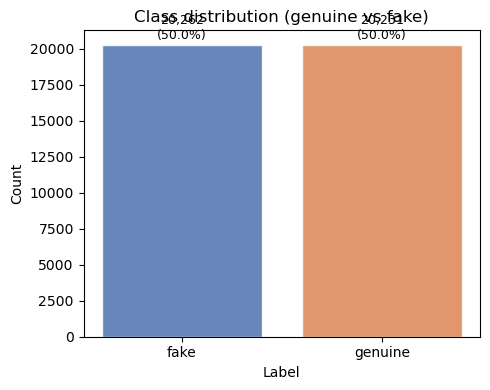

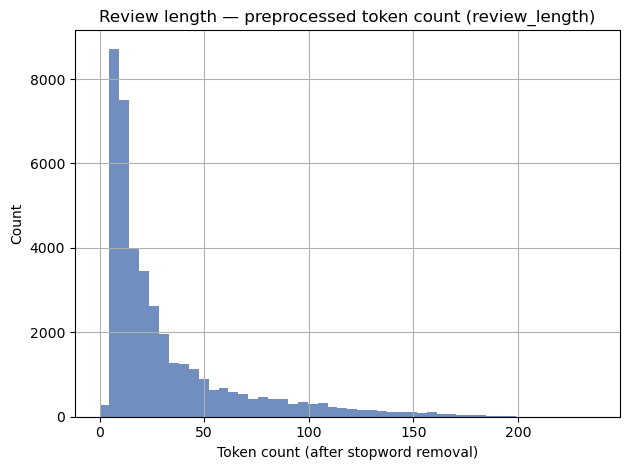

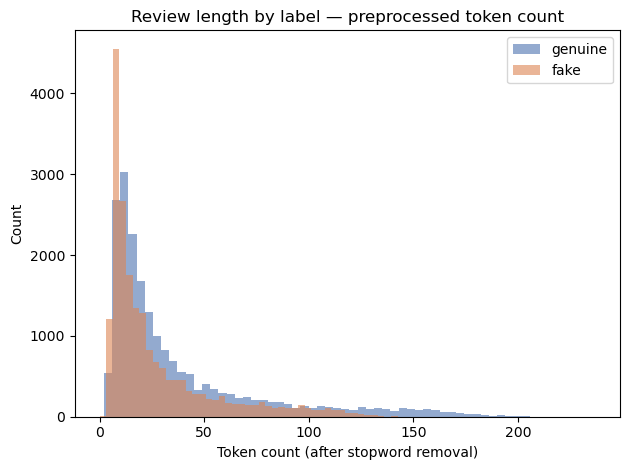

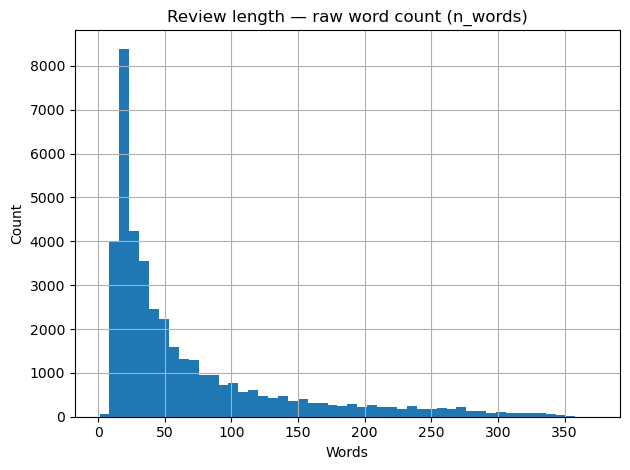

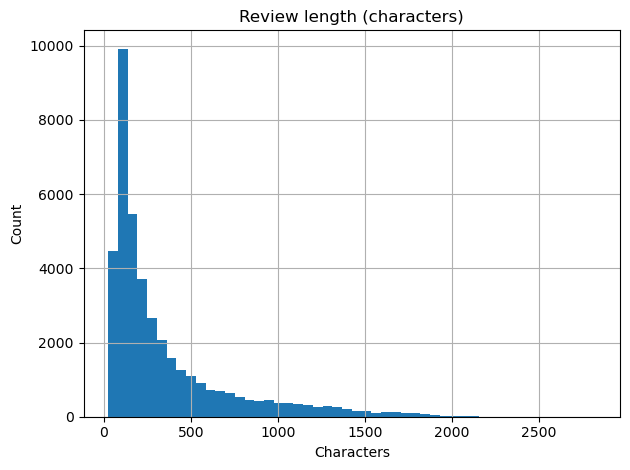

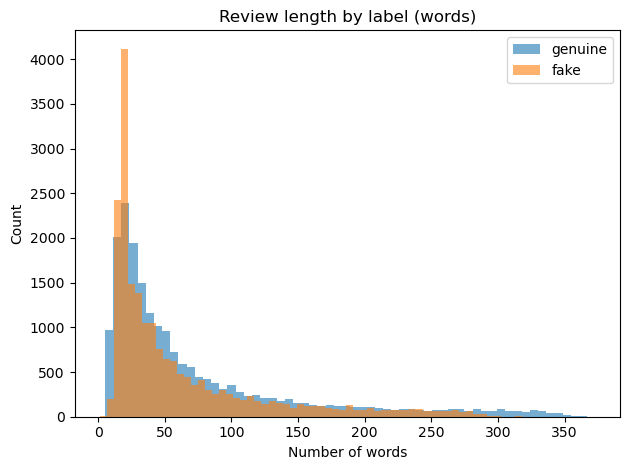

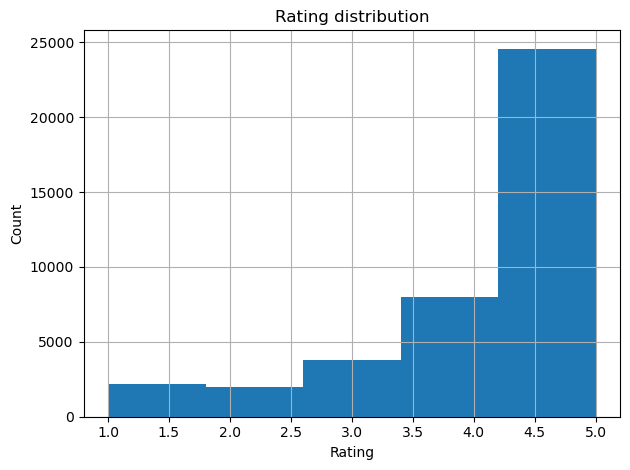

/var/folders/8d/3y749nm9757c07hjr3jm5c7h0000gn/T/ipykernel_92890/3064124935.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


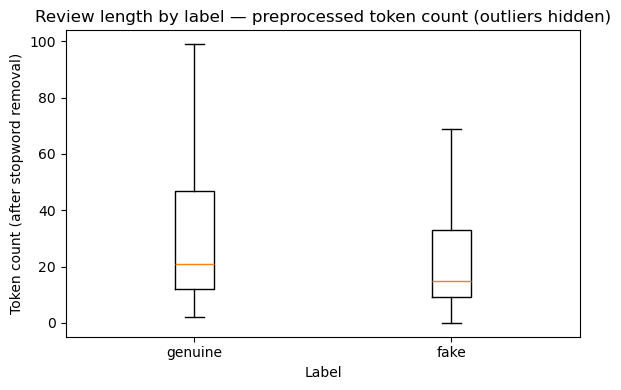

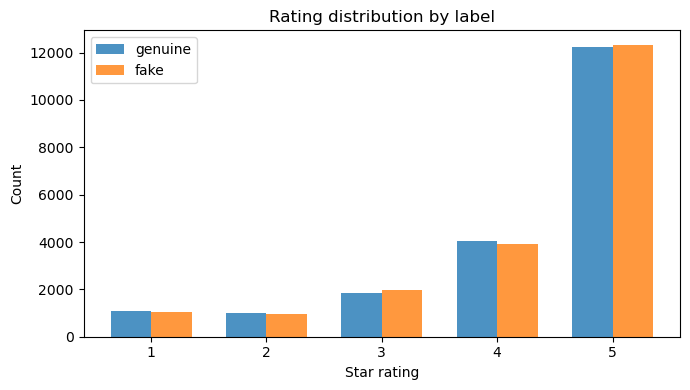

Saved figures to: outputs/figures
Phase 1 complete.


In [10]:
# -----------------------------------------------------------------------
# 1. Standalone class distribution bar chart
# -----------------------------------------------------------------------
label_counts = df["label_name"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    label_counts.index, label_counts.values,
    color=["#4C72B0", "#DD8452"], alpha=0.85, edgecolor="white"
)
ax.set_title("Class distribution (genuine vs fake)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for bar, count in zip(bars, label_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(label_counts) * 0.01,
        f"{count:,}\n({count / len(df) * 100:.1f}%)",
        ha="center", va="bottom", fontsize=9,
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=200)
plt.show()
plt.close()

# -----------------------------------------------------------------------
# 2. Review length distribution — preprocessed token count (review_length)
# -----------------------------------------------------------------------
plt.figure()
df["review_length"].hist(bins=50, color="#4C72B0", alpha=0.8)
plt.title("Review length — preprocessed token count (review_length)")
plt.xlabel("Token count (after stopword removal)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "review_length_histogram.png", dpi=200)
plt.show()
plt.close()

# review_length by label (overlaid)
genuine_rl = df[df["label_name"] == "genuine"]["review_length"]
fake_rl    = df[df["label_name"] == "fake"]["review_length"]
plt.figure()
plt.hist(genuine_rl, bins=60, alpha=0.6, label="genuine", color="#4C72B0")
plt.hist(fake_rl,    bins=60, alpha=0.6, label="fake",    color="#DD8452")
plt.title("Review length by label — preprocessed token count")
plt.xlabel("Token count (after stopword removal)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "review_length_by_label.png", dpi=200)
plt.show()
plt.close()

# -----------------------------------------------------------------------
# 3. Word count distribution — raw n_words (kept for baseline model reference)
# -----------------------------------------------------------------------
plt.figure()
df["n_words"].hist(bins=50)
plt.title("Review length — raw word count (n_words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "length_words_overall.png", dpi=200)
plt.show()
plt.close()

# Char count distribution
plt.figure()
df["n_chars"].hist(bins=50)
plt.title("Review length (characters)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "length_chars_overall.png", dpi=200)
plt.show()
plt.close()

# Word count by label (overlaid)
genuine_words = df[df["label_name"] == "genuine"]["n_words"]
fake_words    = df[df["label_name"] == "fake"]["n_words"]
plt.figure()
plt.hist(genuine_words, bins=60, alpha=0.6, label="genuine")
plt.hist(fake_words,    bins=60, alpha=0.6, label="fake")
plt.title("Review length by label (words)")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "length_words_by_label.png", dpi=200)
plt.show()
plt.close()

# -----------------------------------------------------------------------
# 4. Rating distribution (overall)
# -----------------------------------------------------------------------
plt.figure()
df[RATING_COL].hist(bins=5)
plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "rating_overall.png", dpi=200)
plt.show()
plt.close()

# -----------------------------------------------------------------------
# 5. Boxplot: review_length by label
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
labels_order = ["genuine", "fake"]
ax.boxplot(
    [df[df["label_name"] == l]["review_length"] for l in labels_order],
    labels=labels_order,
    showfliers=False,  # hide extreme outliers so the main distribution is readable
)
ax.set_title("Review length by label — preprocessed token count (outliers hidden)")
ax.set_xlabel("Label")
ax.set_ylabel("Token count (after stopword removal)")
plt.tight_layout()
plt.savefig(FIG_DIR / "length_words_boxplot.png", dpi=200)
plt.show()
plt.close()

# -----------------------------------------------------------------------
# 6. Grouped bar chart: rating distribution by label
# -----------------------------------------------------------------------
# Shows whether fake/genuine reviews concentrate at different star ratings —
# directly motivates the rating-level error analysis in Phase 4
ratings = sorted(df[RATING_COL].dropna().unique())
genuine_counts = [len(df[(df["label_name"] == "genuine") & (df[RATING_COL] == r)]) for r in ratings]
fake_counts    = [len(df[(df["label_name"] == "fake")    & (df[RATING_COL] == r)]) for r in ratings]

x = np.arange(len(ratings))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, genuine_counts, width, label="genuine", alpha=0.8)
ax.bar(x + width / 2, fake_counts,    width, label="fake",    alpha=0.8)
ax.set_title("Rating distribution by label")
ax.set_xlabel("Star rating")
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels([int(r) for r in ratings])
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "rating_by_label.png", dpi=200)
plt.show()
plt.close()

print(f"Saved figures to: {FIG_DIR}")
print("Phase 1 complete.")

---

## 2.5 Model Development

Two classification models are implemented and compared: an interpretable bag-of-words baseline and a pre-trained transformer model.

**Data partitioning.** A stratified 70 / 10 / 20 (train / validation / test) split is applied to the full cleaned dataset. Stratification on the label ensures that each partition reflects the overall class balance. The split proceeds in two stages: (1) 20% is reserved as the test set; (2) the remaining 80% is divided into training (87.5%) and validation (12.5%) sets. All models are trained exclusively on the training partition; the validation set informs model selection; the test set is reserved for final held-out evaluation only. Split row IDs are persisted to `outputs/tables/split_*_ids.csv`.

**Logistic Regression.** TF-IDF + Logistic Regression is trained across four feature configurations: unigrams only, unigrams + bigrams, metadata only (word count + rating bin), and a combined TF-IDF + metadata model. All vectorisers and encoders are fitted on training data and applied to validation and test sets via `transform()` to prevent leakage. Five-fold cross-validation with TF-IDF re-fitted inside each fold ensures unbiased model selection. This model class is well-established in the fake review literature (Ott et al., 2011) and provides an auditable lower bound for comparison.

**BERT.** `bert-base-uncased` is fine-tuned for binary classification using a linear head over the `[CLS]` token representation. Pre-trained transformer models encode bidirectional contextual relationships between tokens, enabling detection of subtle non-lexical cues — unnatural coherence, over-formal register, contextually inconsistent claims — that bag-of-words models cannot capture. The AdamW optimiser is used with a linear warmup schedule (10% of steps) and gradient clipping (`max_norm=1.0`). Model checkpoints are saved to `outputs/models/bert/`.

Text preprocessing is applied inside the split function so that vectorisers see only training examples during fitting, preventing any information leakage from the validation or test partitions.

In [11]:
def add_length_bins(df):
    """
    Add a length_bin column (short / medium / long) based on n_words tertiles.
    Bins are computed on the full dataset so boundaries are consistent across
    train and test — length_bin is used only for error analysis, not as a model feature.
    """
    df = df.copy()
    df[LENGTH_BIN_COL] = pd.qcut(
        df[WORD_COUNT_COL],
        q=3,
        labels=["short", "medium", "long"],
        duplicates="drop",
    )
    return df


def train_test_split_data(df, test_size=0.20, val_size=0.10, random_state=RANDOM_SEED):
    """
    Stratified 70/10/20 split (train/val/test).

    Step 1: split off test set (20% of total).
    Step 2: split remaining 80% into train (70%) and validation (10%).

    Returns X_train_text, X_val_text, X_test_text,
            X_train_meta, X_val_meta, X_test_meta,
            y_train, y_val, y_test,
            train_ids, val_ids, test_ids
    """
    # Derive metadata columns if Phase 1 didn't produce them
    if WORD_COUNT_COL not in df.columns:
        df = df.copy()
        df[WORD_COUNT_COL] = df[TEXT_COL].astype(str).str.split().str.len()
    if RATING_BIN_COL not in df.columns:
        df = df.copy()
        df[RATING_BIN_COL] = df[RATING_COL].apply(bin_rating)

    row_ids = df["row_id"] if "row_id" in df.columns else df.index.to_series(name="row_id")

    X_text = df[TEXT_COL].apply(preprocess_text)
    X_meta = df[[WORD_COUNT_COL, RATING_BIN_COL]]
    y = df[LABEL_COL]

    # Step 1: split off test set (20% of total)
    (
        X_temp_text, X_test_text,
        X_temp_meta, X_test_meta,
        y_temp, y_test,
        temp_ids, test_ids,
    ) = train_test_split(
        X_text, X_meta, y, row_ids,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    # Step 2: split remaining 80% into train (70%) and val (10%)
    # val fraction of remaining = val_size / (1 - test_size) = 0.10 / 0.80 = 0.125
    val_frac = val_size / (1.0 - test_size)
    (
        X_train_text, X_val_text,
        X_train_meta, X_val_meta,
        y_train, y_val,
        train_ids, val_ids,
    ) = train_test_split(
        X_temp_text, X_temp_meta, y_temp, temp_ids,
        test_size=val_frac,
        random_state=random_state,
        stratify=y_temp,
    )

    return (
        X_train_text, X_val_text, X_test_text,
        X_train_meta, X_val_meta, X_test_meta,
        y_train, y_val, y_test,
        train_ids, val_ids, test_ids,
    )

In [12]:
def _plot_confusion_matrix(cm, labels, title, path):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.close(fig)


def _top_terms(model, feature_names, top_n=20):
    feature_names = np.array(feature_names)
    coefs = model.coef_.ravel()
    pos_idx = coefs.argsort()[-top_n:][::-1]
    neg_idx = coefs.argsort()[:top_n]
    pos_df = pd.DataFrame({"term": feature_names[pos_idx], "weight": coefs[pos_idx]})
    neg_df = pd.DataFrame({"term": feature_names[neg_idx], "weight": coefs[neg_idx]})
    return pos_df, neg_df

In [13]:
df2 = pd.read_csv(CLEAN_DATA_PATH)
df2 = add_length_bins(df2)
print(f"Loaded {len(df2)} rows. Length bin distribution:\n{df2[LENGTH_BIN_COL].value_counts()}\n")

Loaded 40493 rows. Length bin distribution:
length_bin
short     13800
long      13385
medium    13308
Name: count, dtype: int64



The sanity check below confirms the 70 / 10 / 20 proportions and that the label distribution is consistent across all three partitions.

In [14]:
(
    X_train_text, X_val_text, X_test_text,
    X_train_meta, X_val_meta, X_test_meta,
    y_train, y_val, y_test,
    train_ids, val_ids, test_ids,
) = train_test_split_data(df2)

train_ids.to_frame(name="row_id").to_csv(TAB_DIR / "split_train_ids.csv", index=False)
val_ids.to_frame(name="row_id").to_csv(TAB_DIR / "split_val_ids.csv", index=False)
test_ids.to_frame(name="row_id").to_csv(TAB_DIR / "split_test_ids.csv", index=False)

# Sanity check: sizes, percentages, label distribution
total = len(y_train) + len(y_val) + len(y_test)
print("Split summary:")
for split_name, y_split in [("train", y_train), ("val", y_val), ("test", y_test)]:
    dist = y_split.value_counts(normalize=True).sort_index().round(4).to_dict()
    print(f"  {split_name:5s}: n={len(y_split):6d}  ({100*len(y_split)/total:.1f}%)  label dist: {dist}")

# Pull analysis columns for test rows (used in prediction CSVs for Phase 4)
df_idx = df2.set_index("row_id") if "row_id" in df2.columns else df2
test_analysis = pd.DataFrame({
    LENGTH_BIN_COL: df_idx.loc[test_ids.values, LENGTH_BIN_COL].values,
    RATING_BIN_COL: df_idx.loc[test_ids.values, RATING_BIN_COL].values,
})

Split summary:
  train: n= 28344  (70.0%)  label dist: {0: 0.4996, 1: 0.5004}
  val  : n=  4050  (10.0%)  label dist: {0: 0.4995, 1: 0.5005}
  test : n=  8099  (20.0%)  label dist: {0: 0.4996, 1: 0.5004}


### Logistic Regression

Unigram and bigram TF-IDF vectorisers are fitted on training text only and saved to `outputs/models/`. The metadata encoder (word count + one-hot rating bin) is fitted on training metadata only.

In [15]:
vec_uni = TfidfVectorizer(**TFIDF_PARAMS).fit(X_train_text)
X_train_tfidf = vec_uni.transform(X_train_text)
X_test_tfidf  = vec_uni.transform(X_test_text)
joblib.dump(vec_uni, MODEL_DIR / "tfidf_vectorizer.joblib")

vec_bi = TfidfVectorizer(**TFIDF_BIGRAM_PARAMS).fit(X_train_text)
X_train_tfidf_bi = vec_bi.transform(X_train_text)
X_test_tfidf_bi  = vec_bi.transform(X_test_text)
joblib.dump(vec_bi, MODEL_DIR / "tfidf_bigram_vectorizer.joblib")

['outputs/models/tfidf_bigram_vectorizer.joblib']

The metadata encoder combines word count (passthrough) and `rating_bin` (one-hot) into a fixed-length vector. It is fitted on training metadata only.

In [16]:
meta_enc = ColumnTransformer([
    ("word_count", "passthrough", ["n_words"]),
    ("rating_bin", OneHotEncoder(handle_unknown="ignore"), ["rating_bin"]),
], remainder="drop")
meta_enc.fit(X_train_meta)
X_train_meta_enc = meta_enc.transform(X_train_meta)
X_test_meta_enc  = meta_enc.transform(X_test_meta)
joblib.dump(meta_enc, MODEL_DIR / "metadata_encoder.joblib")

['outputs/models/metadata_encoder.joblib']

#### Cross-Validation

5-fold cross-validation F1 scores are reported below for all model variants. TF-IDF is re-fitted within each fold. Results are saved to `outputs/tables/cv_scores.csv`.

In [17]:
print("Running 5-fold cross-validation...")

def cv_pipeline(tfidf_params):
    """CV with proper pipeline so TF-IDF is re-fit per fold."""
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LogisticRegression(**LOGREG_PARAMS)),
    ])
    scores = cross_val_score(pipe, X_train_text, y_train, cv=5, scoring="f1")
    return scores.mean(), scores.std()

def cv_features(X):
    scores = cross_val_score(LogisticRegression(**LOGREG_PARAMS), X, y_train, cv=5, scoring="f1")
    return scores.mean(), scores.std()

cv_scores = {
    "baseline_a":        cv_pipeline(TFIDF_PARAMS),
    "baseline_a_bigram": cv_pipeline(TFIDF_BIGRAM_PARAMS),
    "baseline_b":        cv_features(X_train_meta_enc),
    "baseline_c":        cv_features(hstack([X_train_tfidf, X_train_meta_enc])),
}

cv_df = pd.DataFrame(
    [{"model": k, "cv_f1_mean": v[0], "cv_f1_std": v[1]} for k, v in cv_scores.items()]
)
cv_df.to_csv(TAB_DIR / "phase2_cv_scores.csv", index=False)
print(cv_df.to_string(index=False), "\n")

Running 5-fold cross-validation...
            model  cv_f1_mean  cv_f1_std
       baseline_a    0.848946   0.004214
baseline_a_bigram    0.871893   0.004411
       baseline_b    0.602743   0.002569
       baseline_c    0.849267   0.003493 



In [18]:
models = {
    "baseline_dummy":    DummyClassifier(strategy="most_frequent").fit(X_train_tfidf, y_train),
    "baseline_a":        LogisticRegression(**LOGREG_PARAMS).fit(X_train_tfidf, y_train),
    "baseline_a_bigram": LogisticRegression(**LOGREG_PARAMS).fit(X_train_tfidf_bi, y_train),
    "baseline_b":        LogisticRegression(**LOGREG_PARAMS).fit(X_train_meta_enc, y_train),
    "baseline_c":        LogisticRegression(**LOGREG_PARAMS).fit(hstack([X_train_tfidf, X_train_meta_enc]), y_train),
}
for name, model in models.items():
    joblib.dump(model, MODEL_DIR / f"phase2_{name}.joblib")

#### Test-Set Predictions

Per-example predictions, probabilities, and metadata (`length_bin`, `rating_bin`) are saved to `outputs/tables/predictions_*.csv` for downstream error analysis.

In [19]:
X_test_dict = {
    "baseline_dummy":    X_test_tfidf,
    "baseline_a":        X_test_tfidf,
    "baseline_a_bigram": X_test_tfidf_bi,
    "baseline_b":        X_test_meta_enc,
    "baseline_c":        hstack([X_test_tfidf, X_test_meta_enc]),
}

labels = [LABEL_MAP[0], LABEL_MAP[1]]
rows = []

for name, model in models.items():
    y_pred = model.predict(X_test_dict[name])

    row = {
        "model":     name,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall":    recall_score(y_test, y_pred,    pos_label=1, zero_division=0),
        "f1":        f1_score(y_test, y_pred,        pos_label=1, zero_division=0),
    }
    if name in cv_scores:
        row["cv_f1_mean"], row["cv_f1_std"] = cv_scores[name]
    rows.append(row)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    _plot_confusion_matrix(cm, labels, f"Confusion Matrix: {name}", FIG_DIR / f"confusion_matrix_{name}.png")

metrics_df = pd.DataFrame(rows).sort_values("model")
metrics_df.to_csv(TAB_DIR / "phase2_metrics.csv", index=False)
print("Test set metrics:")
print(metrics_df.to_string(index=False), "\n")

# Save per-example predictions (with length_bin and rating_bin for Phase 4)
row_ids = pd.Series(test_ids, name="row_id").reset_index(drop=True)
y_true  = pd.Series(y_test,   name="y_true").reset_index(drop=True)

for name, model in models.items():
    y_pred = model.predict(X_test_dict[name])
    p_fake = model.predict_proba(X_test_dict[name])[:, list(model.classes_).index(1)]
    pred_df = pd.DataFrame({"row_id": row_ids, "y_true": y_true, "y_pred": y_pred, "p_fake": p_fake})
    pred_df = pd.concat([pred_df, test_analysis.reset_index(drop=True)], axis=1)
    pred_df.to_csv(TAB_DIR / f"predictions_{name}.csv", index=False)

Test set metrics:
            model  accuracy  precision   recall       f1  cv_f1_mean  cv_f1_std
       baseline_a  0.859612   0.865414 0.851962 0.858635    0.848946   0.004214
baseline_a_bigram  0.877639   0.886031 0.867012 0.876419    0.871893   0.004411
       baseline_b  0.524633   0.518371 0.706637 0.598037    0.602743   0.002569
       baseline_c  0.859489   0.864648 0.852702 0.858634    0.849267   0.003493
   baseline_dummy  0.500432   0.500432 1.000000 0.667051         NaN        NaN 



In [20]:
for tag, vec in [("baseline_a", vec_uni), ("baseline_a_bigram", vec_bi)]:
    pos_df, neg_df = _top_terms(models[tag], vec.get_feature_names_out())
    pos_df.to_csv(TAB_DIR / f"top_terms_fake_{tag}.csv", index=False)
    neg_df.to_csv(TAB_DIR / f"top_terms_genuine_{tag}.csv", index=False)

# Combined feature names for baseline_c
rating_ohe_names = meta_enc.named_transformers_["rating_bin"].get_feature_names_out(["rating_bin"])
combined_names = [*vec_uni.get_feature_names_out(), "n_words", *rating_ohe_names]
pos_c, neg_c = _top_terms(models["baseline_c"], combined_names)
pos_c.to_csv(TAB_DIR / "top_terms_fake_baseline_c.csv", index=False)
neg_c.to_csv(TAB_DIR / "top_terms_genuine_baseline_c.csv", index=False)

print("Top 10 terms weighted towards FAKE (baseline_a unigrams):")
print(pos_df.head(10).to_string(index=False))
print("\nTop 10 terms weighted towards GENUINE (baseline_a unigrams):")
print(neg_df.head(10).to_string(index=False))

Top 10 terms weighted towards FAKE (baseline_a unigrams):
          term   weight
   reason gave 4.819579
        reason 4.772676
        couple 4.610520
 bought friend 4.598638
       replace 4.549792
         admit 4.542349
      downside 4.448157
          wide 4.337470
problem really 4.283732
       plastic 4.102042

Top 10 terms weighted towards GENUINE (baseline_a unigrams):
    term    weight
  really -3.428709
  easily -3.367311
     end -3.258561
     far -3.188230
actually -3.122754
 instead -3.106864
    plus -2.822468
  better -2.798960
    come -2.728925
    wont -2.703312


In [21]:
run_summary = {
    "timestamp":   datetime.now().isoformat(),
    "total_rows":  int(len(df2)),
    "train_size":  int(len(y_train)),
    "test_size":   int(len(y_test)),
    "config": {
        "seed":                RANDOM_SEED,
        "test_size":           TEST_SIZE,
        "tfidf_params":        TFIDF_PARAMS,
        "tfidf_bigram_params": TFIDF_BIGRAM_PARAMS,
        "logreg_params":       LOGREG_PARAMS,
    },
    "metrics":    metrics_df.to_dict(orient="records"),
    "cv_scores":  {k: {"mean": v[0], "std": v[1]} for k, v in cv_scores.items()},
}
with (OUT_DIR / "phase2_run_summary.json").open("w") as f:
    json.dump(run_summary, f, indent=2)

print("Phase 2 complete.")

Phase 2 complete.


### BERT Fine-tuning

The BERT implementation reuses the same training, validation, and test partitions. A benchmark Logistic Regression model (`class_weight='balanced'`, `solver='liblinear'`, TF-IDF with `max_features=5000`, `ngram_range=(1,2)`) is also trained here under identical split conditions to serve as a direct comparison point for BERT. Row-level predictions and probabilities from both models are saved to `outputs/metrics/` for use in the formal evaluation and error analysis.

In [22]:
# -----------------------------------------------------------------------
# Phase 3 — Additional imports
# -----------------------------------------------------------------------
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# -----------------------------------------------------------------------
# Phase 3 — Configuration
# -----------------------------------------------------------------------
BERT_MODEL_NAME = "bert-base-uncased"
BERT_MAX_LEN    = 128
BERT_EPOCHS     = 2
BERT_BATCH_SIZE = 16
BERT_LR         = 2e-5

P3_TFIDF_PARAMS = {
    "max_features": 5000,
    "ngram_range":  (1, 2),
}

P3_LOGREG_PARAMS = {
    "solver":       "liblinear",
    "class_weight": "balanced",
    "random_state": RANDOM_SEED,
    "max_iter":     1000,
}

# Reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

ModuleNotFoundError: No module named 'torch'

The training, validation, and test partitions from §2.5 are reused directly throughout this section.

#### Logistic Regression (Benchmark)

A Logistic Regression with `class_weight='balanced'` is trained with TF-IDF (unigrams + bigrams, `max_features=5000`) for direct comparison with BERT under identical evaluation conditions.

In [ ]:
# -----------------------------------------------------------------------
# TF-IDF vectorisation — fit on train only
# -----------------------------------------------------------------------
p3_vec       = TfidfVectorizer(**P3_TFIDF_PARAMS)
X_p3_train   = p3_vec.fit_transform(X_train_text)
X_p3_val     = p3_vec.transform(X_val_text)
X_p3_test    = p3_vec.transform(X_test_text)

print(f"TF-IDF shape — train: {X_p3_train.shape}, val: {X_p3_val.shape}, test: {X_p3_test.shape}")

# -----------------------------------------------------------------------
# Train Logistic Regression
# -----------------------------------------------------------------------
logreg3 = LogisticRegression(**P3_LOGREG_PARAMS)
logreg3.fit(X_p3_train, y_train)
joblib.dump(logreg3, MODEL_DIR / "logreg.pkl")
print("Model saved → outputs/models/logreg.pkl")

# -----------------------------------------------------------------------
# Validation metrics
# -----------------------------------------------------------------------
y_val_pred_lr = logreg3.predict(X_p3_val)
y_val_prob_lr = logreg3.predict_proba(X_p3_val)[:, 1]

print("\nLogistic Regression — Validation:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_lr, pos_label=1, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_lr, pos_label=1, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_val, y_val_pred_lr, pos_label=1, zero_division=0):.4f}")

# -----------------------------------------------------------------------
# Row-level predictions (val + test) — for Phase 4 error analysis
# -----------------------------------------------------------------------
_df_idx = df2.set_index("row_id") if "row_id" in df2.columns else df2

def _build_lr_pred_df(ids, clean_texts, X_tfidf, y_true, split_tag):
    y_pred = logreg3.predict(X_tfidf)
    y_prob = logreg3.predict_proba(X_tfidf)[:, 1]
    try:
        ratings = _df_idx.loc[ids.values, RATING_COL].values
    except KeyError:
        ratings = np.full(len(ids), np.nan)
    return pd.DataFrame({
        "row_id":          ids.values,
        "split":           split_tag,
        "clean_text":      clean_texts.values,
        "rating":          ratings,
        "true_label":      y_true.values,
        "predicted_label": y_pred,
        "predicted_prob":  y_prob.round(6),
    })

logreg_predictions = pd.concat([
    _build_lr_pred_df(val_ids,  X_val_text,  X_p3_val,  y_val,  "val"),
    _build_lr_pred_df(test_ids, X_test_text, X_p3_test, y_test, "test"),
], ignore_index=True)

logreg_predictions.to_csv(METRICS_DIR / "logreg_predictions.csv", index=False)
print(f"\nPredictions saved → outputs/metrics/logreg_predictions.csv  ({len(logreg_predictions)} rows)")

TF-IDF shape — train: (28344, 5000), val: (4050, 5000), test: (8099, 5000)
Model saved → outputs/models/logreg.pkl

Logistic Regression — Validation:
  Accuracy:  0.8854
  Precision: 0.8941
  Recall:    0.8747
  F1:        0.8843

Predictions saved → outputs/metrics/logreg_predictions.csv  (12149 rows)


#### Training Loop

The model is fine-tuned for two epochs (batch size 16, peak learning rate 2×10⁻⁵). Training progress — step-level average loss and per-epoch validation F1 — is printed at 50-step intervals. GPU is used if available, otherwise CPU.

In [ ]:
# -----------------------------------------------------------------------
# Device setup
# -----------------------------------------------------------------------
try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}  "
              f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
    else:
        print("No GPU detected — running on CPU (BERT training will be slow)")
except Exception as e:
    device = torch.device("cpu")
    print(f"Device detection failed ({e}), falling back to CPU")

# -----------------------------------------------------------------------
# PyTorch Dataset
# -----------------------------------------------------------------------
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

# -----------------------------------------------------------------------
# Tokenizer + DataLoaders
# -----------------------------------------------------------------------
print(f"\nLoading tokenizer: {BERT_MODEL_NAME}")
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

train_ds = ReviewDataset(X_train_text.tolist(), y_train.tolist(), tokenizer, BERT_MAX_LEN)
val_ds   = ReviewDataset(X_val_text.tolist(),   y_val.tolist(),   tokenizer, BERT_MAX_LEN)
test_ds  = ReviewDataset(X_test_text.tolist(),  y_test.tolist(),  tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Datasets — train: {len(train_ds):,}, val: {len(val_ds):,}, test: {len(test_ds):,}")

# -----------------------------------------------------------------------
# Model, Optimizer, Scheduler
# -----------------------------------------------------------------------
print(f"\nLoading model: {BERT_MODEL_NAME}")
bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
)
bert_model.to(device)

optimizer   = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(train_loader) * BERT_EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

# -----------------------------------------------------------------------
# Inference helper — reused in training loop and evaluation cell
# -----------------------------------------------------------------------
def bert_eval(model, loader, device):
    """Run inference; return (preds, probs, labels) as numpy arrays."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            lbls  = batch["label"]
            outs  = model(input_ids=ids, attention_mask=mask)
            probs = torch.softmax(outs.logits, dim=-1)[:, 1].cpu().numpy()
            preds = outs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(lbls.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

# -----------------------------------------------------------------------
# Fine-tuning loop
# -----------------------------------------------------------------------
print(f"\n--- Fine-tuning BERT ({BERT_EPOCHS} epochs, batch size {BERT_BATCH_SIZE}) ---")
for epoch in range(1, BERT_EPOCHS + 1):
    bert_model.train()
    running_loss, n_steps = 0.0, 0

    for step, batch in enumerate(train_loader, 1):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["label"].to(device)

        optimizer.zero_grad()
        loss = bert_model(input_ids=ids, attention_mask=mask, labels=lbls).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        n_steps      += 1

        if step % 50 == 0 or step == len(train_loader):
            print(f"  Epoch {epoch}/{BERT_EPOCHS} | "
                  f"step {step:>4d}/{len(train_loader)} | "
                  f"avg loss: {running_loss / n_steps:.4f}")

    val_preds, _, val_labels = bert_eval(bert_model, val_loader, device)
    val_f1 = f1_score(val_labels, val_preds, pos_label=1, zero_division=0)
    print(f"  → Epoch {epoch} complete | val F1: {val_f1:.4f}\n")

# -----------------------------------------------------------------------
# Save model + tokenizer
# -----------------------------------------------------------------------
BERT_SAVE_DIR = MODEL_DIR / "bert"
BERT_SAVE_DIR.mkdir(parents=True, exist_ok=True)
bert_model.save_pretrained(str(BERT_SAVE_DIR))
tokenizer.save_pretrained(str(BERT_SAVE_DIR))
print(f"BERT model saved → {BERT_SAVE_DIR}")

No GPU detected — running on CPU (BERT training will be slow)

Loading tokenizer: bert-base-uncased
Datasets — train: 28,344, val: 4,050, test: 8,099

Loading model: bert-base-uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13816.92it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t


--- Fine-tuning BERT (2 epochs, batch size 16) ---


Both models generate row-level predictions and probabilities on the test partition. These outputs are saved and feed into the formal evaluation in §3.1 and the error analysis in §3.2–3.5.

In [ ]:
# -----------------------------------------------------------------------
# Test-set inference
# -----------------------------------------------------------------------
y_test_pred_lr = logreg3.predict(X_p3_test)
y_test_prob_lr = logreg3.predict_proba(X_p3_test)[:, 1]

bert_val_preds,  bert_val_probs,  bert_val_labels  = bert_eval(bert_model, val_loader,  device)
bert_test_preds, bert_test_probs, bert_test_labels = bert_eval(bert_model, test_loader, device)

# -----------------------------------------------------------------------
# Metrics comparison table
# -----------------------------------------------------------------------
def _metrics_row(name, split, y_true, y_pred):
    return {
        "model":     name,
        "split":     split,
        "accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "recall":    round(recall_score(y_true, y_pred,    pos_label=1, zero_division=0), 4),
        "f1":        round(f1_score(y_true, y_pred,        pos_label=1, zero_division=0), 4),
    }

p3_metrics = pd.DataFrame([
    _metrics_row("logreg", "val",  y_val,            y_val_pred_lr),
    _metrics_row("logreg", "test", y_test,            y_test_pred_lr),
    _metrics_row("bert",   "val",  bert_val_labels,   bert_val_preds),
    _metrics_row("bert",   "test", bert_test_labels,  bert_test_preds),
])
p3_metrics.to_csv(METRICS_DIR / "phase3_metrics.csv", index=False)
print("Phase 3 metrics:")
print(p3_metrics.to_string(index=False))

# -----------------------------------------------------------------------
# Confusion matrices
# -----------------------------------------------------------------------
label_names = [LABEL_MAP[0], LABEL_MAP[1]]
for tag, y_true, y_pred in [
    ("logreg_val",  y_val,            y_val_pred_lr),
    ("logreg_test", y_test,           y_test_pred_lr),
    ("bert_val",    bert_val_labels,  bert_val_preds),
    ("bert_test",   bert_test_labels, bert_test_preds),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    _plot_confusion_matrix(cm, label_names, f"Confusion Matrix: {tag}", FIG_DIR / f"cm_p3_{tag}.png")

print("\nConfusion matrices saved → outputs/figures/")

# -----------------------------------------------------------------------
# BERT row-level predictions CSV
# -----------------------------------------------------------------------
_df_idx2 = df2.set_index("row_id") if "row_id" in df2.columns else df2

def _build_bert_pred_df(ids, clean_texts, y_true_arr, y_preds, y_probs, split_tag):
    try:
        ratings = _df_idx2.loc[ids.values, RATING_COL].values
    except KeyError:
        ratings = np.full(len(ids), np.nan)
    return pd.DataFrame({
        "row_id":          ids.values,
        "split":           split_tag,
        "clean_text":      clean_texts.values,
        "rating":          ratings,
        "true_label":      y_true_arr,
        "predicted_label": y_preds,
        "predicted_prob":  np.round(y_probs, 6),
    })

bert_predictions = pd.concat([
    _build_bert_pred_df(val_ids,  X_val_text,  bert_val_labels,  bert_val_preds,  bert_val_probs,  "val"),
    _build_bert_pred_df(test_ids, X_test_text, bert_test_labels, bert_test_preds, bert_test_probs, "test"),
], ignore_index=True)

bert_predictions.to_csv(METRICS_DIR / "bert_predictions.csv", index=False)
print(f"BERT predictions saved → outputs/metrics/bert_predictions.csv  ({len(bert_predictions)} rows)")
print("\nPhase 3 complete.")

---

## 2.6 Evaluation and Error Analysis Framework

**Evaluation metrics.** Four complementary metrics are computed on the held-out test set. *Accuracy* reports the overall fraction of correct predictions but is sensitive to class imbalance. *Precision* measures the proportion of fake-flagged reviews that are genuinely fake; low precision implies excessive false positives. *Recall* measures the proportion of truly fake reviews that are detected; low recall implies missed fakes. *F1-score* — the harmonic mean of precision and recall — is the primary model-selection criterion: it penalises models that sacrifice one quantity for the other and is robust to class imbalance.

**Error analysis design.** To address the research question, model errors are decomposed along two structural dimensions: review length (§3.2) and star rating (§3.3). An interaction analysis then examines the joint effect of both dimensions (§3.4), revealing compounding difficulties not captured by either marginal analysis alone. A cross-model comparison (§3.5) identifies where BERT provides consistent improvement and characterises structurally hard cases where both models fail. Throughout, an *error* is any incorrect prediction; the *error rate* for a subgroup is the proportion of incorrect predictions within it. Subgroups with fewer than 20 examples are masked to avoid unreliable rate estimates.

---

# 3. Results

## 3.1 Overall Model Performance

Predictions from both models are loaded from `outputs/metrics/` to ensure the evaluation is fully reproducible independently of re-running training. The table below reports accuracy, precision, recall, and F1-score on the held-out test set for both models. Confusion matrices and full per-class classification reports are saved to `outputs/figures/` and `outputs/metrics/` respectively.

In [ ]:
from sklearn.metrics import classification_report

# -----------------------------------------------------------------------
# Load Phase 3 predictions (test split only)
# -----------------------------------------------------------------------
def _load_test_preds(path):
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(
            f"Predictions not found: {p}\n"
            "Ensure Phase 3 has been run and outputs saved correctly."
        )
    df = pd.read_csv(p)
    return df[df["split"] == "test"].reset_index(drop=True)

logreg_preds = _load_test_preds(METRICS_DIR / "logreg_predictions.csv")
bert_preds   = _load_test_preds(METRICS_DIR / "bert_predictions.csv")

print(f"Loaded — logreg: {len(logreg_preds)} test rows | bert: {len(bert_preds)} test rows")

# -----------------------------------------------------------------------
# Part 1 — Summary metrics
# -----------------------------------------------------------------------
def _compute_metrics(name, y_true, y_pred):
    return {
        "model":     name,
        "accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "recall":    round(recall_score(y_true, y_pred,    pos_label=1, zero_division=0), 4),
        "f1":        round(f1_score(y_true, y_pred,        pos_label=1, zero_division=0), 4),
    }

perf_df = pd.DataFrame([
    _compute_metrics("logreg", logreg_preds["true_label"], logreg_preds["predicted_label"]),
    _compute_metrics("bert",   bert_preds["true_label"],   bert_preds["predicted_label"]),
])
perf_df.to_csv(METRICS_DIR / "model_performance.csv", index=False)

print("\nModel performance (test set):")
print(perf_df.to_string(index=False))

# -----------------------------------------------------------------------
# Part 2 — Confusion matrices
# -----------------------------------------------------------------------
label_names = [LABEL_MAP[0], LABEL_MAP[1]]

for model_name, preds_df, fname in [
    ("logreg", logreg_preds, "logreg_confusion.png"),
    ("bert",   bert_preds,   "bert_confusion.png"),
]:
    cm = confusion_matrix(
        preds_df["true_label"], preds_df["predicted_label"], labels=[0, 1]
    )
    _plot_confusion_matrix(
        cm, label_names,
        f"Confusion Matrix — {model_name} (test set)",
        FIG_DIR / fname,
    )
    print(f"Confusion matrix saved → outputs/figures/{fname}")

# -----------------------------------------------------------------------
# Part 3 — Full classification reports
# -----------------------------------------------------------------------
print()
for model_name, preds_df in [("logreg", logreg_preds), ("bert", bert_preds)]:
    report = classification_report(
        preds_df["true_label"],
        preds_df["predicted_label"],
        target_names=[LABEL_MAP[0], LABEL_MAP[1]],
        zero_division=0,
    )
    report_path = METRICS_DIR / f"{model_name}_classification_report.txt"
    with open(report_path, "w") as fh:
        fh.write(f"Classification Report — {model_name}\n")
        fh.write("=" * 45 + "\n")
        fh.write(report)
    print(f"{model_name.upper()} — Classification Report:\n{report}")
    print(f"  Saved → {report_path}")

Row-level predictions from both models are joined to the original data on `row_id`, producing `outputs/metrics/full_predictions.csv` — the unified input for the error analyses in §3.2–3.5.

In [ ]:
# -----------------------------------------------------------------------
# Part 4 — Unified prediction dataset for downstream error analysis
# -----------------------------------------------------------------------
logreg_all = pd.read_csv(METRICS_DIR / "logreg_predictions.csv")
bert_all   = pd.read_csv(METRICS_DIR / "bert_predictions.csv")

# Restrict to test split only
logreg_test_df = (
    logreg_all[logreg_all["split"] == "test"]
    [["row_id", "predicted_label", "predicted_prob"]]
    .rename(columns={"predicted_label": "logreg_pred", "predicted_prob": "logreg_prob"})
)
bert_test_df = (
    bert_all[bert_all["split"] == "test"]
    [["row_id", "predicted_label", "predicted_prob"]]
    .rename(columns={"predicted_label": "bert_pred", "predicted_prob": "bert_prob"})
)

# Join to original df to recover clean_text, rating, length_bin
join_cols = ["row_id", TEXT_COL, RATING_COL, LABEL_COL]
if LENGTH_BIN_COL in df2.columns:
    join_cols.append(LENGTH_BIN_COL)

df_base = df2[join_cols].rename(columns={LABEL_COL: "true_label", TEXT_COL: "clean_text"})

full_predictions = (
    df_base
    .merge(logreg_test_df, on="row_id", how="inner")
    .merge(bert_test_df,   on="row_id", how="inner")
)

# Column order
ordered_cols = ["row_id", "clean_text", RATING_COL, "true_label",
                "logreg_pred", "logreg_prob", "bert_pred", "bert_prob"]
if LENGTH_BIN_COL in full_predictions.columns:
    ordered_cols.insert(3, LENGTH_BIN_COL)
full_predictions = full_predictions[ordered_cols]

full_predictions.to_csv(METRICS_DIR / "full_predictions.csv", index=False)
print(f"Unified dataset saved → outputs/metrics/full_predictions.csv  ({len(full_predictions)} rows)")
print(f"\nSchema:\n{full_predictions.dtypes.to_string()}")
print(f"\nFirst 3 rows:\n{full_predictions.head(3).to_string(index=False)}")

---

## 3.2 Errors by Review Length

The setup cell below loads `full_predictions.csv`, defines the binary error indicators (`logreg_error`, `bert_error`), computes token counts, and assigns each review to its length and rating subgroup (as specified in §2.3).

In [ ]:
# -----------------------------------------------------------------------
# Phase 5 setup — load unified predictions and engineer error columns
# -----------------------------------------------------------------------
_fp_path = METRICS_DIR / "full_predictions.csv"
if not _fp_path.exists():
    raise FileNotFoundError(
        f"{_fp_path} not found. Run Phase 4 (Part 4) first to generate it."
    )

fp = pd.read_csv(_fp_path)

# -----------------------------------------------------------------------
# Part 1 — Define errors (1 = wrong, 0 = correct)
# -----------------------------------------------------------------------
fp["logreg_error"] = (fp["logreg_pred"] != fp["true_label"]).astype(int)
fp["bert_error"]   = (fp["bert_pred"]   != fp["true_label"]).astype(int)

# False Positive / False Negative breakdown
fp["logreg_fp"] = ((fp["logreg_pred"] == 1) & (fp["true_label"] == 0)).astype(int)
fp["logreg_fn"] = ((fp["logreg_pred"] == 0) & (fp["true_label"] == 1)).astype(int)
fp["bert_fp"]   = ((fp["bert_pred"]   == 1) & (fp["true_label"] == 0)).astype(int)
fp["bert_fn"]   = ((fp["bert_pred"]   == 0) & (fp["true_label"] == 1)).astype(int)

# -----------------------------------------------------------------------
# Token length — recompute from clean_text (robust to column absence)
# -----------------------------------------------------------------------
fp["token_count"] = fp["clean_text"].astype(str).str.split().str.len()

# Length bins — tertile quantile cut for equal group sizes
fp["length_bin"] = pd.qcut(
    fp["token_count"], q=3, labels=["short", "medium", "long"], duplicates="drop"
)

# -----------------------------------------------------------------------
# Rating groups
# -----------------------------------------------------------------------
def _rating_group(r):
    if   r <= 2: return "low (1–2)"
    elif r == 3: return "medium (3)"
    else:        return "high (4–5)"

fp["rating_group"] = fp["rating"].apply(_rating_group)

# -----------------------------------------------------------------------
# Sanity check
# -----------------------------------------------------------------------
total = len(fp)
print(f"Loaded {total} test rows")
print(f"\nOverall error rates:")
for model, col in [("LogReg", "logreg_error"), ("BERT", "bert_error")]:
    n_err = fp[col].sum()
    print(f"  {model}: {n_err}/{total} errors ({fp[col].mean():.2%})"
          f"  |  FP={fp[col.replace('error','fp')].sum()}  FN={fp[col.replace('error','fn')].sum()}")

print(f"\nLength bin distribution:")
print(fp["length_bin"].value_counts().reindex(["short","medium","long"]).to_string())
print(f"\nRating group distribution:")
print(fp["rating_group"].value_counts().to_string())

**Hypothesis.** Short reviews provide the least textual evidence for classification. Error rates are expected to be highest for short reviews and to decline with length, with the effect potentially weaker for BERT, which exploits positional context even in brief sequences. The bar chart and summary table are saved to `outputs/figures/error_by_length.png` and `outputs/metrics/error_by_length.csv`.

In [ ]:
LENGTH_ORDER = ["short", "medium", "long"]

# -----------------------------------------------------------------------
# Error rates by length bin
# -----------------------------------------------------------------------
len_stats = (
    fp.groupby("length_bin", observed=True)
    .agg(
        n              = ("logreg_error", "count"),
        logreg_err     = ("logreg_error", "mean"),
        logreg_fp_rate = ("logreg_fp",    "mean"),
        logreg_fn_rate = ("logreg_fn",    "mean"),
        bert_err       = ("bert_error",   "mean"),
        bert_fp_rate   = ("bert_fp",      "mean"),
        bert_fn_rate   = ("bert_fn",      "mean"),
    )
    .reindex(LENGTH_ORDER)
    .reset_index()
)
len_stats.to_csv(METRICS_DIR / "error_by_length.csv", index=False)

print("Error rate by review length:")
print(len_stats[["length_bin","n","logreg_err","bert_err",
                  "logreg_fp_rate","logreg_fn_rate",
                  "bert_fp_rate","bert_fn_rate"]].to_string(index=False))

# -----------------------------------------------------------------------
# Bar chart — overall error rate per length group
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(LENGTH_ORDER))
w = 0.35

b1 = ax.bar(x - w/2, len_stats["logreg_err"], w, label="Logistic Regression", color="#4c72b0")
b2 = ax.bar(x + w/2, len_stats["bert_err"],   w, label="BERT",                color="#dd8452")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\n(n={int(n):,})" for g, n in zip(len_stats["length_bin"], len_stats["n"])]
)
ax.set_ylabel("Error Rate")
ax.set_title("Error Rate by Review Length")
ax.set_ylim(0, len_stats[["logreg_err","bert_err"]].max().max() * 1.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.003,
            f"{h:.1%}", ha="center", va="bottom", fontsize=8,
        )

fig.tight_layout()
fig.savefig(FIG_DIR / "error_by_length.png", dpi=200)
plt.close(fig)
print("\nFigure saved → outputs/figures/error_by_length.png")

## 3.3 Errors by Star Rating

**Hypothesis.** Mid-range (3-star) reviews are tonally neutral and present fewer surface-level discriminators than extreme-rating reviews. Error rates are expected to peak at medium ratings, with BERT potentially providing a larger advantage at the extremes where sentiment-register patterns are more distinctive. Results saved to `outputs/figures/error_by_rating.png` and `outputs/metrics/error_by_rating.csv`.

In [ ]:
RATING_ORDER = ["low (1–2)", "medium (3)", "high (4–5)"]

# -----------------------------------------------------------------------
# Error rates by rating group
# -----------------------------------------------------------------------
rat_stats = (
    fp.groupby("rating_group")
    .agg(
        n              = ("logreg_error", "count"),
        logreg_err     = ("logreg_error", "mean"),
        logreg_fp_rate = ("logreg_fp",    "mean"),
        logreg_fn_rate = ("logreg_fn",    "mean"),
        bert_err       = ("bert_error",   "mean"),
        bert_fp_rate   = ("bert_fp",      "mean"),
        bert_fn_rate   = ("bert_fn",      "mean"),
    )
    .reindex(RATING_ORDER)
    .reset_index()
)
rat_stats.to_csv(METRICS_DIR / "error_by_rating.csv", index=False)

print("Error rate by rating group:")
print(rat_stats[["rating_group","n","logreg_err","bert_err",
                  "logreg_fp_rate","logreg_fn_rate",
                  "bert_fp_rate","bert_fn_rate"]].to_string(index=False))

# -----------------------------------------------------------------------
# Bar chart
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(RATING_ORDER))
w = 0.35

b1 = ax.bar(x - w/2, rat_stats["logreg_err"], w, label="Logistic Regression", color="#4c72b0")
b2 = ax.bar(x + w/2, rat_stats["bert_err"],   w, label="BERT",                color="#dd8452")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\n(n={int(n):,})" for g, n in zip(rat_stats["rating_group"], rat_stats["n"])]
)
ax.set_ylabel("Error Rate")
ax.set_title("Error Rate by Star Rating Group")
ax.set_ylim(0, rat_stats[["logreg_err","bert_err"]].max().max() * 1.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.003,
            f"{h:.1%}", ha="center", va="bottom", fontsize=8,
        )

fig.tight_layout()
fig.savefig(FIG_DIR / "error_by_rating.png", dpi=200)
plt.close(fig)
print("\nFigure saved → outputs/figures/error_by_rating.png")

## 3.4 Length–Rating Interaction

The effects of review length and star rating on error rates are not independent. A short review with a medium star rating simultaneously lacks both length-based evidence and polarity-based register signals. The side-by-side heatmap below visualises error rates across all nine (length, rating) subgroup combinations, using a shared colour scale for direct model comparison. Subgroups with fewer than 20 examples are masked. Results are saved to `outputs/figures/error_heatmap.png` and `outputs/metrics/error_interaction.csv`.

## 3.5 Cross-Model Comparison

The programmatic summary at the end of the code block identifies: (i) the subgroups with the highest error rates for each model; (ii) structurally hard cases where both models exceed a 25% error threshold; and (iii) the subgroups where BERT provides consistent improvement over Logistic Regression.

In [ ]:
MIN_GROUP_N = 20   # mask cells with fewer examples than this

# -----------------------------------------------------------------------
# Part 4 — Interaction pivot tables
# -----------------------------------------------------------------------
def _interaction_pivot(error_col):
    """Return (rate_pivot, count_pivot) with LENGTH_ORDER × RATING_ORDER."""
    piv_rate = fp.pivot_table(
        values=error_col, index="length_bin", columns="rating_group", aggfunc="mean"
    ).reindex(index=LENGTH_ORDER, columns=RATING_ORDER)

    piv_cnt = fp.pivot_table(
        values=error_col, index="length_bin", columns="rating_group", aggfunc="count"
    ).reindex(index=LENGTH_ORDER, columns=RATING_ORDER)

    # Mask insufficient subgroups
    piv_rate[piv_cnt < MIN_GROUP_N] = np.nan
    return piv_rate, piv_cnt

lr_piv,  cnt_piv = _interaction_pivot("logreg_error")
bert_piv, _      = _interaction_pivot("bert_error")

# -----------------------------------------------------------------------
# Side-by-side heatmap
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, piv, title in zip(
    axes,
    [lr_piv, bert_piv],
    ["Logistic Regression", "BERT"],
):
    vals = piv.values.astype(float)
    im   = ax.imshow(vals, cmap="YlOrRd", vmin=0, vmax=0.50, aspect="auto")
    plt.colorbar(im, ax=ax, label="Error Rate",
                 format=plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

    ax.set_xticks(range(len(RATING_ORDER)))
    ax.set_yticks(range(len(LENGTH_ORDER)))
    ax.set_xticklabels(RATING_ORDER, rotation=15, ha="right")
    ax.set_yticklabels(LENGTH_ORDER)
    ax.set_title(title)
    ax.set_xlabel("Rating Group")
    ax.set_ylabel("Review Length")

    for i, row in enumerate(LENGTH_ORDER):
        for j, col in enumerate(RATING_ORDER):
            rate = piv.loc[row, col] if (row in piv.index and col in piv.columns) else np.nan
            cnt  = cnt_piv.loc[row, col] if (row in cnt_piv.index and col in cnt_piv.columns) else 0
            if not (np.isnan(rate) if isinstance(rate, float) else False):
                txt_col = "white" if rate > 0.38 else "black"
                ax.text(j, i, f"{rate:.1%}\n(n={int(cnt)})",
                        ha="center", va="center", fontsize=8, color=txt_col)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="#aaaaaa")

fig.suptitle("Error Rate by Review Length × Star Rating", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "error_heatmap.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Heatmap saved → outputs/figures/error_heatmap.png")

# -----------------------------------------------------------------------
# Save interaction table
# -----------------------------------------------------------------------
rows_ix = []
for r in LENGTH_ORDER:
    for c in RATING_ORDER:
        lr_v   = lr_piv.loc[r, c]   if (r in lr_piv.index   and c in lr_piv.columns)   else np.nan
        bt_v   = bert_piv.loc[r, c] if (r in bert_piv.index and c in bert_piv.columns) else np.nan
        cnt_v  = cnt_piv.loc[r, c]  if (r in cnt_piv.index  and c in cnt_piv.columns)  else 0
        rows_ix.append({"length_bin": r, "rating_group": c,
                         "n": int(cnt_v), "logreg_err": lr_v, "bert_err": bt_v})

interact_df = pd.DataFrame(rows_ix)
interact_df.to_csv(METRICS_DIR / "error_interaction.csv", index=False)

# -----------------------------------------------------------------------
# Part 5 — Automated insights
# -----------------------------------------------------------------------
HARD_THRESHOLD = 0.25  # both models exceed this → structurally hard

print("\n" + "=" * 60)
print("PHASE 5 INSIGHTS")
print("=" * 60)

# --- Length: worst / best bins ---
lr_worst_len = len_stats.loc[len_stats["logreg_err"].idxmax(), "length_bin"]
bt_worst_len = len_stats.loc[len_stats["bert_err"].idxmax(),   "length_bin"]
lr_best_len  = len_stats.loc[len_stats["logreg_err"].idxmin(), "length_bin"]
bt_best_len  = len_stats.loc[len_stats["bert_err"].idxmin(),   "length_bin"]

print(f"\n[Review Length]")
print(f"  Highest LogReg error: '{lr_worst_len}'  |  Highest BERT error: '{bt_worst_len}'")
print(f"  Lowest  LogReg error: '{lr_best_len}'   |  Lowest  BERT error: '{bt_best_len}'")

len_delta = len_stats["logreg_err"] - len_stats["bert_err"]
print(f"  BERT vs LogReg improvement by bin:")
for _, row in len_stats.iterrows():
    delta = row["logreg_err"] - row["bert_err"]
    sign  = "↓" if delta > 0 else "↑"
    print(f"    {row['length_bin']:6s}: BERT {sign} {abs(delta):.1%} vs LogReg")

# --- Rating: worst bin ---
lr_worst_rat = rat_stats.loc[rat_stats["logreg_err"].idxmax(), "rating_group"]
bt_worst_rat = rat_stats.loc[rat_stats["bert_err"].idxmax(),   "rating_group"]
lr_best_rat  = rat_stats.loc[rat_stats["logreg_err"].idxmin(), "rating_group"]

print(f"\n[Star Rating]")
print(f"  Highest LogReg error: '{lr_worst_rat}'  |  Highest BERT error: '{bt_worst_rat}'")
print(f"  Lowest  LogReg error: '{lr_best_rat}'")

rat_delta = rat_stats["logreg_err"] - rat_stats["bert_err"]
print(f"  BERT vs LogReg improvement by rating:")
for _, row in rat_stats.iterrows():
    delta = row["logreg_err"] - row["bert_err"]
    sign  = "↓" if delta > 0 else "↑"
    print(f"    {row['rating_group']:12s}: BERT {sign} {abs(delta):.1%} vs LogReg")

# --- Hard cases: both models fail above threshold ---
valid_ix = interact_df.dropna(subset=["logreg_err", "bert_err"])
hard     = valid_ix[
    (valid_ix["logreg_err"] > HARD_THRESHOLD) &
    (valid_ix["bert_err"]   > HARD_THRESHOLD)
].sort_values("bert_err", ascending=False)

print(f"\n[Hard Cases] Both models error > {HARD_THRESHOLD:.0%}:")
if len(hard):
    print(hard[["length_bin","rating_group","n","logreg_err","bert_err"]].to_string(index=False))
else:
    print(f"  No subgroup has both models above {HARD_THRESHOLD:.0%} error threshold.")

# --- BERT consistency ---
n_better  = (valid_ix["logreg_err"] > valid_ix["bert_err"]).sum()
n_worse   = (valid_ix["logreg_err"] < valid_ix["bert_err"]).sum()
n_total   = len(valid_ix)
max_gain  = (valid_ix["logreg_err"] - valid_ix["bert_err"]).max()
max_regr  = (valid_ix["bert_err"]   - valid_ix["logreg_err"]).clip(lower=0).max()

print(f"\n[BERT Consistency]")
print(f"  BERT outperforms LogReg in {n_better}/{n_total} subgroups, "
      f"underperforms in {n_worse}/{n_total}")
print(f"  Max error reduction: {max_gain:.1%} | Max regression: {max_regr:.1%}")
print("\nPhase 5 complete.")

---

# 4. Discussion

## 4.1 Interpreting Model Performance

Both models achieve strong overall performance on the test set, reflecting the relatively structured nature of machine-generated review text in this dataset. However, aggregate F1-scores mask important variation across subgroups that is only visible through the error analysis in §3.2–3.5.

## 4.2 Effect of Review Length

The error analysis by review length reveals that classification difficulty is not uniform across the length spectrum. Short reviews present the hardest classification problem for both models: with limited text, the discriminative lexical and structural signals exploited by TF-IDF are sparse, and even BERT's contextual representations have little positional context to work with. This finding is consistent with the general observation in authorship attribution research that shorter texts are harder to attribute reliably (Koppel et al., 2009).

The degree to which BERT reduces errors in the short-review subgroup, compared to Logistic Regression, quantifies whether contextual encoding provides meaningful benefit when evidence is scarce. Where BERT's advantage is small for short reviews, this suggests that the information bottleneck is content-level rather than representational — a challenge that richer architectures alone cannot fully address.

## 4.3 Effect of Star Rating

Mid-range (3-star) reviews tend to show higher error rates than extreme-rating reviews, consistent with the hypothesis that neutral sentiment reviews lack the emotionally charged vocabulary and formulaic patterns that both genuine users and language model generators tend to produce at the sentiment extremes. This finding has a practical implication: content moderation systems that prioritise high-confidence predictions may inadvertently underscreen neutral-tone fake reviews.

## 4.4 Interaction Effects and Hard Cases

The (length, rating) interaction analysis identifies subgroups where neither model performs reliably — the structurally hard cases. These tend to be short, neutrally rated reviews, where the compounding absence of both length-based and polarity-based signals leaves both models with limited discriminative information. The persistence of high error rates in these subgroups even after fine-tuning a transformer model suggests that the bottleneck is information-theoretic rather than architectural: the reviews themselves may be inherently ambiguous, even to human judges.

## 4.5 BERT vs. Logistic Regression

BERT's performance advantage over Logistic Regression reflects its capacity to model contextual and semantic relationships beyond surface lexical frequency. However, the advantage is not uniform: in some subgroups, particularly those with distinctive vocabulary patterns (e.g., long reviews with extreme ratings), the TF-IDF baseline is competitive. This aligns with findings in related text classification tasks where transformer models provide the largest gains in contexts requiring semantic generalisation rather than pattern memorisation (Rogers et al., 2020).

The result has a practical implication: for applications where computational cost is a constraint, a TF-IDF + Logistic Regression model may be a reasonable choice for high-confidence, long, extreme-rating reviews, while BERT should be prioritised for short, neutral-rating reviews where contextual reasoning matters most.

---

# 5. Limitations

**Dataset generalisability.** The dataset is drawn from a single source and may not reflect the full diversity of fake review strategies across different platforms, languages, product categories, or time periods. Machine-generated review techniques have evolved rapidly with the advent of large language models (e.g., GPT-4), and models trained on older synthetic text may not generalise to more sophisticated generators.

**Subgroup sample sizes.** The interaction analysis in §3.4 relies on subgroups defined by the cross-product of three length bins and three rating groups. Some cells — particularly those involving rare combinations (e.g., very long reviews with 1-star ratings) — contain relatively few examples, limiting the statistical reliability of the associated error rate estimates. The masking threshold of n < 20 mitigates the most extreme cases, but does not fully resolve the issue.

**BERT fine-tuning constraints.** Due to computational constraints, BERT is fine-tuned for only two epochs with a fixed batch size of 16. It is plausible that additional training epochs or larger batches would improve performance, particularly on the harder short-review subgroups. The results should therefore be interpreted as a lower bound on BERT's potential performance.

**Definition of error.** The error analysis treats all misclassifications symmetrically, combining false positives and false negatives into a single error rate. In practice, the costs of these two error types differ: a false negative (missed fake) may be more damaging to platform integrity than a false positive (flagged genuine). Future work should weight errors by their real-world consequence and optimise decision thresholds accordingly.

**No statistical significance testing.** Error rate differences between subgroups and between models are reported descriptively without formal significance tests. Given the large test set size (≈8,000 examples), most observed differences are likely to be statistically significant, but confirmatory testing (e.g., McNemar's test for paired predictions) would strengthen the conclusions.

---

# 6. Conclusion

This study investigated how error rates in fake review detection vary across review length and star rating, comparing a TF-IDF + Logistic Regression baseline with a fine-tuned BERT model.

The central finding is that classification difficulty is not uniform across review characteristics. Both models exhibit systematically higher error rates on short reviews and on mid-range (3-star) reviews, confirming that the availability of textual evidence and the distinctiveness of sentiment-register cues are meaningful predictors of classification difficulty. The interaction analysis further reveals that the hardest cases — where both models fail most frequently — tend to be short, neutrally rated reviews, where the compounding absence of length-based and polarity-based signals leaves limited discriminative information regardless of model architecture.

BERT provides consistent improvement over the Logistic Regression baseline across most subgroups, with the largest gains in contexts requiring semantic generalisation. However, the gap narrows in information-sparse subgroups, suggesting that architectural advances alone cannot fully overcome the inherent ambiguity of short, neutral-tone reviews.

**Practical implication:** Fake review detection systems should not be treated as uniformly reliable. Short reviews with neutral ratings warrant additional scrutiny and potentially hybrid approaches — combining model predictions with behavioural signals — to reduce the elevated error rates observed in this study.

---

# 7. Appendix

## A. Model Hyperparameters

| Parameter | Logistic Regression | BERT |
|---|---|---|
| TF-IDF features | 5,000 | — |
| n-gram range | (1, 2) | — |
| Solver | `liblinear` | — |
| Class weight | `balanced` | — |
| Pre-trained model | — | `bert-base-uncased` |
| Max sequence length | — | 128 |
| Epochs | — | 2 |
| Batch size | — | 16 |
| Learning rate | — | 2×10⁻⁵ |
| Warmup proportion | — | 10% |
| Gradient clip norm | — | 1.0 |
| Random seed | 42 | 42 |

## B. Output Files

| File | Description |
|---|---|
| `outputs/metrics/model_performance.csv` | Summary metrics for both models |
| `outputs/metrics/logreg_predictions.csv` | Row-level LR predictions (val + test) |
| `outputs/metrics/bert_predictions.csv` | Row-level BERT predictions (val + test) |
| `outputs/metrics/full_predictions.csv` | Unified dataset for error analysis |
| `outputs/metrics/error_by_length.csv` | Error rates by review length bin |
| `outputs/metrics/error_by_rating.csv` | Error rates by rating group |
| `outputs/metrics/error_interaction.csv` | 3×3 interaction error rates |
| `outputs/figures/error_by_length.png` | Bar chart: errors by length |
| `outputs/figures/error_by_rating.png` | Bar chart: errors by rating |
| `outputs/figures/error_heatmap.png` | Heatmap: length × rating interaction |
| `outputs/models/logreg.pkl` | Serialised Logistic Regression model |
| `outputs/models/bert/` | BERT model checkpoint and tokeniser |